In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

df = pd.read_csv("../data/monthly.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df[df['Date'] >= '1971-01-01'].copy().reset_index(drop=True)

In [3]:
# Create lag features and additional time-based features
def create_lag_features(df, lags=[1, 2, 3, 6, 12]):
    df = df.copy()
    for lag in lags:
        df[f'lag_{lag}'] = df['Price'].shift(lag)
    
    # Additional time-based features
    df['month'] = df['Date'].dt.month
    df['year'] = df['Date'].dt.year
    df['rolling_mean_3'] = df['Price'].shift(1).rolling(3).mean()
    df['rolling_mean_6'] = df['Price'].shift(1).rolling(6).mean()
    df['rolling_std_3'] = df['Price'].shift(1).rolling(3).std()
    
    df = df.dropna().reset_index(drop=True)
    return df

df_features = create_lag_features(df)
print(f"Shape after feature engineering: {df_features.shape}")
print(df_features.columns.tolist())

Shape after feature engineering: (650, 12)
['Date', 'Price', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'month', 'year', 'rolling_mean_3', 'rolling_mean_6', 'rolling_std_3']


In [4]:
# Define features and target
test_size = 24

feature_cols = ['lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 
                'month', 'year', 'rolling_mean_3', 'rolling_mean_6', 'rolling_std_3']

train_ml = df_features.iloc[:-test_size]
test_ml = df_features.iloc[-test_size:]

X_train = train_ml[feature_cols]
y_train = train_ml['Price']
X_test = test_ml[feature_cols]
y_test = test_ml['Price']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (626, 10)
X_test shape: (24, 10)


In [5]:
# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# XGBoost
xgb_model = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, rf_pred)
mae_xgb = mean_absolute_error(y_test, xgb_pred)

print(f"Random Forest MAE: {mae_rf:.2f}")
print(f"XGBoost MAE:       {mae_xgb:.2f}")
print(f"Naive baseline:    1129.51")

Random Forest MAE: 1158.22
XGBoost MAE:       1175.68
Naive baseline:    1129.51


          Feature  RF_Importance  XGB_Importance
0           lag_1       0.655975        0.345136
6            year       0.094834        0.638439
7  rolling_mean_3       0.091329        0.005459
8  rolling_mean_6       0.055968        0.004660
1           lag_2       0.053329        0.003677
2           lag_3       0.028475        0.000234
4          lag_12       0.017874        0.000325
3           lag_6       0.001247        0.001461
9   rolling_std_3       0.000501        0.000216
5           month       0.000469        0.000392


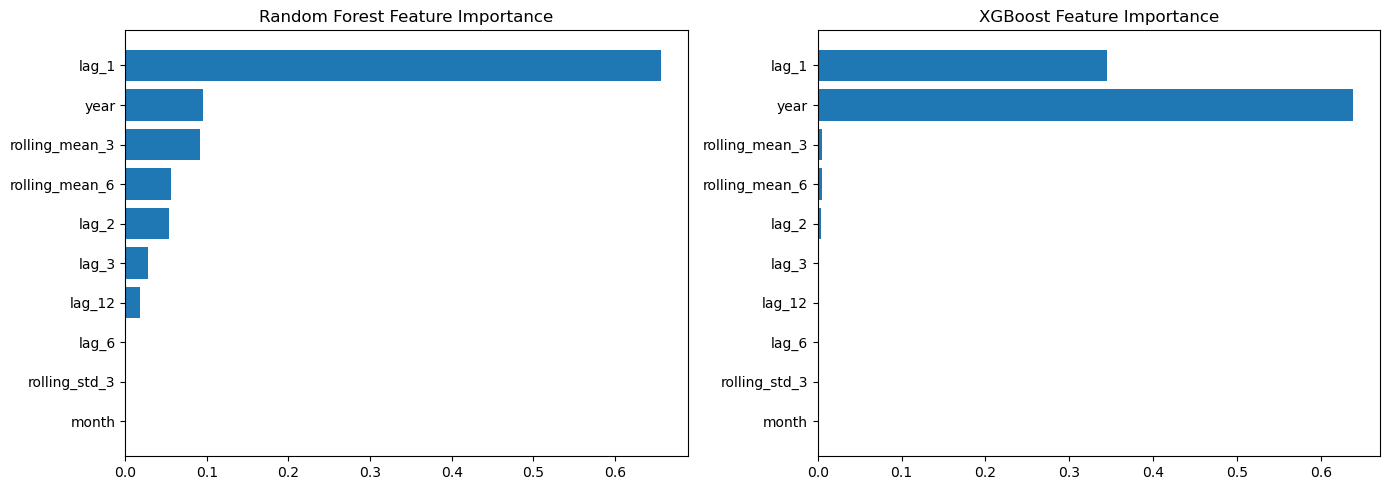

In [6]:
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'RF_Importance': rf_model.feature_importances_,
    'XGB_Importance': xgb_model.feature_importances_
}).sort_values('RF_Importance', ascending=False)

print(feature_importance)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(feature_importance['Feature'], feature_importance['RF_Importance'])
axes[0].set_title('Random Forest Feature Importance')
axes[0].invert_yaxis()

axes[1].barh(feature_importance['Feature'], feature_importance['XGB_Importance'])
axes[1].set_title('XGBoost Feature Importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

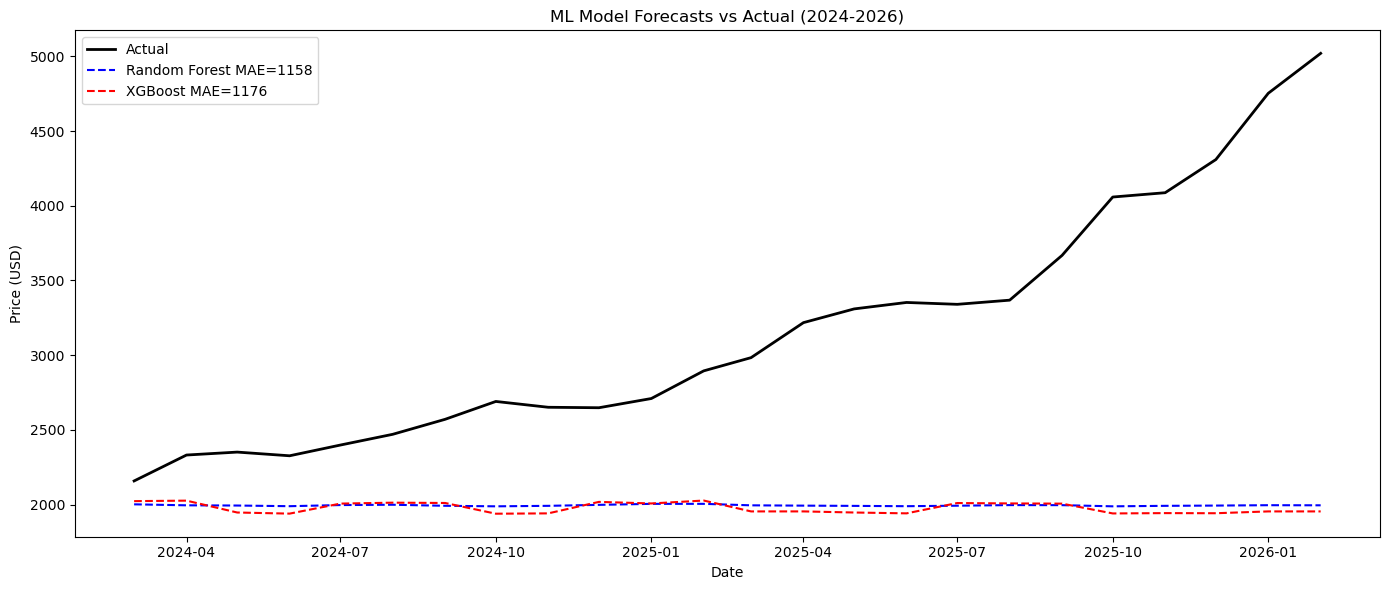

In [7]:
# Plotting predictions vs actual
plt.figure(figsize=(14, 6))
plt.plot(test_ml['Date'], y_test, label='Actual', color='black', linewidth=2)
plt.plot(test_ml['Date'], rf_pred, label=f'Random Forest MAE={mae_rf:.0f}', linestyle='--', color='blue')
plt.plot(test_ml['Date'], xgb_pred, label=f'XGBoost MAE={mae_xgb:.0f}', linestyle='--', color='red')
plt.title('ML Model Forecasts vs Actual (2024-2026)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()